<a href="https://colab.research.google.com/github/antonio-flores-github/Marketing-Campaign-Response-Prediction-ML-Classifier-Comparison/blob/main/PRACTICA_ML_Antonio_Flores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📦 Sección 1 — Importación de Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)

# ── Modelos ──────────────────────────────────────────────────
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier          # pip install xgboost
from lightgbm import LGBMClassifier        # pip install lightgbm

print('✅ Librerías importadas correctamente.')

✅ Librerías importadas correctamente.


# 📂 Sección 2 — Carga del Dataset de Enero (Entrenamiento)

In [ ]:
from google.colab import files
uploaded = files.upload()   # Selecciona el archivo de Enero

dataset_path = 'marketing_campaign_retail_Enero.xlsx'
data = pd.read_excel(dataset_path)

print('Primeras filas del dataset:')
display(data.head())

print('\nInformación del dataset:')
data.info()

Saving marketing_campaign_retail_Enero.xlsx to marketing_campaign_retail_Enero (3).xlsx
Primeras filas del dataset:


,Client ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Client ID            2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurc

In [ ]:
print("Valores únicos para las columnas seleccionadas:\n")
selected_columns = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain','Z_Revenue','Z_CostContact']
for col in selected_columns:
    print(f"Columna '{col}': {data[col].unique()}")

Valores únicos para las columnas seleccionadas:

Columna 'AcceptedCmp3': [0 1]
Columna 'AcceptedCmp4': [0 1]
Columna 'AcceptedCmp5': [0 1]
Columna 'AcceptedCmp1': [0 1]
Columna 'AcceptedCmp2': [0 1]
Columna 'Response': [1 0]
Columna 'Complain': [0 1]
Columna 'Z_Revenue': [11]
Columna 'Z_CostContact': [3]


# 🔧 Sección 3 — Preprocesamiento

In [ ]:
# Eliminar columnas irrelevantes o que no serán usadas
columns_to_drop = ['Client ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue']
data_processed = data.drop(columns=columns_to_drop)

# Imputar valores nulos en 'Income' si existen, antes del one-hot encoding para evitar problemas con NaNs
# Se usa la mediana para ser robusto a outliers
if 'Income' in data_processed.columns:
    data_processed['Income'].fillna(data_processed['Income'].median(), inplace=True)

# One-Hot Encoding de variables categóricas
# Identificar todas las columnas categóricas a codificar, incluyendo 'Education' y 'Marital_Status'
categorical_cols_for_encoding = [
    'Education', 'Marital_Status',
    'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain'
]
data_encoded = pd.get_dummies(data_processed, columns=categorical_cols_for_encoding, drop_first=True)

# Verificar valores nulos después de todas las transformaciones (deberían ser 0 si Income fue imputado)
print(f'Valores nulos después de imputar y codificar: {data_encoded.isnull().sum().sum()}')

# Escalar variables numéricas (todas excepto la variable objetivo y las que ya son dummies/categoricas)
# Se filtra por tipo de dato para asegurar que solo se escalen columnas numéricas no binarias
numerical_columns = [col for col in data_encoded.columns
                     if data_encoded[col].dtype in ['int64', 'float64']
                     and col not in ['Response']]

scaler = StandardScaler()
data_encoded[numerical_columns] = scaler.fit_transform(data_encoded[numerical_columns])

print('Datos preprocesados:')
display(data_encoded.head())

Valores nulos después de imputar y codificar: 0
Datos preprocesados:


/tmp/ipykernel_7207/3571152080.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_processed['Income'].fillna(data_processed['Income'].median(), inplace=True)


,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,AcceptedCmp3_1,AcceptedCmp4_1,AcceptedCmp5_1,AcceptedCmp1_1,AcceptedCmp2_1,Complain_1
0,-0.985345,0.235696,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,...,True,False,False,False,False,False,False,False,False,False
1,-1.235733,-0.235454,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,...,True,False,False,False,False,False,False,False,False,False
2,-0.317643,0.773999,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,...,False,True,False,False,False,False,False,False,False,False
3,1.268149,-1.022355,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,...,False,True,False,False,False,False,False,False,False,False
4,1.017761,0.241888,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,...,False,False,False,False,False,False,False,False,False,False


# ✂️ Sección 4 — División Train / Test

In [ ]:
X = data_encoded.drop(columns=['Response'])
y = data_encoded['Response']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f'Entrenamiento: {X_train.shape}')
print(f'Prueba:        {X_test.shape}')

Entrenamiento: (1568, 33)
Prueba:        (672, 33)


# 🤖 Sección 5 — Entrenamiento de Múltiples Modelos

In [ ]:
# Diccionario con todos los modelos a comparar
models = {
    'Random Forest':         RandomForestClassifier(random_state=42),
    'Logistic Regression':   LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree':         DecisionTreeClassifier(random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(random_state=42),
    'AdaBoost':              AdaBoostClassifier(random_state=42),
    'XGBoost':               XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    'LightGBM':              LGBMClassifier(random_state=42, verbose=-1),
    'SVM':                   SVC(random_state=42, probability=True),
    'KNN':                   KNeighborsClassifier(),
    'Naive Bayes':           GaussianNB(),
}

# Entrenar todos los modelos
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'✅ {name} entrenado.')

✅ Random Forest entrenado.
✅ Logistic Regression entrenado.
✅ Decision Tree entrenado.
✅ Gradient Boosting entrenado.
✅ AdaBoost entrenado.
✅ XGBoost entrenado.
✅ LightGBM entrenado.
✅ SVM entrenado.
✅ KNN entrenado.
✅ Naive Bayes entrenado.


# 📊 Sección 6 — Comparación de Precisión entre Modelos

,Modelo,Accuracy (Test),Accuracy (CV-5)
1,Logistic Regression,0.8899,0.8871
7,SVM,0.8884,0.8786
3,Gradient Boosting,0.8810,0.8862
6,LightGBM,0.8795,0.8777
4,AdaBoost,0.8795,0.8781
0,Random Forest,0.8735,0.8781
5,XGBoost,0.8661,0.8750
8,KNN,0.8497,0.8571
2,Decision Tree,0.8155,0.8446
9,Naive Bayes,0.7798,0.8192


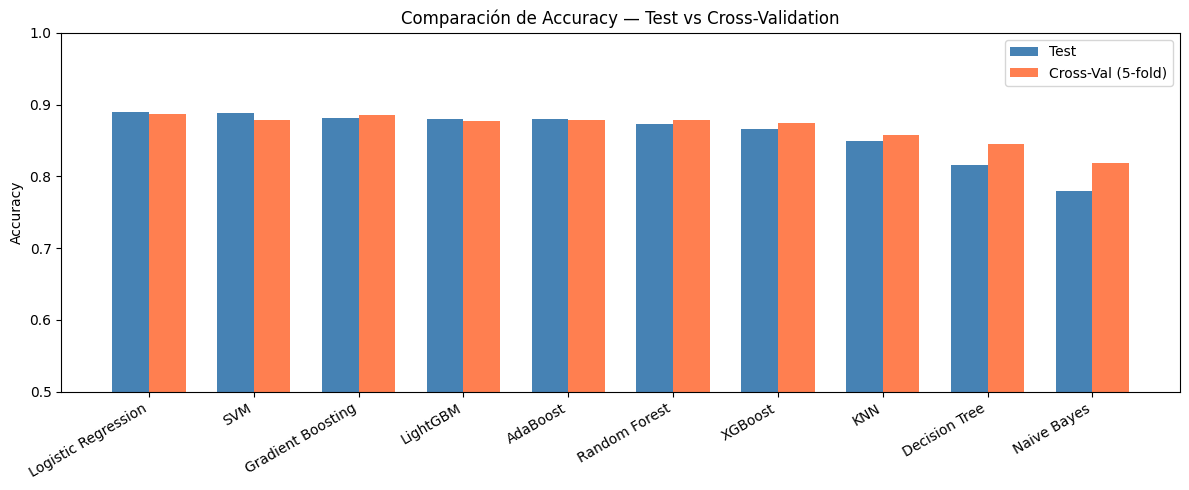

In [ ]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    cv     = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
    results.append({'Modelo': name, 'Accuracy (Test)': round(acc, 4),
                    'Accuracy (CV-5)': round(cv, 4)})

results_df = pd.DataFrame(results).sort_values('Accuracy (Test)', ascending=False)
display(results_df)

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
width = 0.35

ax.bar(x - width/2, results_df['Accuracy (Test)'], width, label='Test', color='steelblue')
ax.bar(x + width/2, results_df['Accuracy (CV-5)'], width, label='Cross-Val (5-fold)', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Modelo'], rotation=30, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('Comparación de Accuracy — Test vs Cross-Validation')
ax.legend()
plt.tight_layout()
plt.show()

# 🔍 Sección 7 — Matrices de Confusión (todos los modelos)

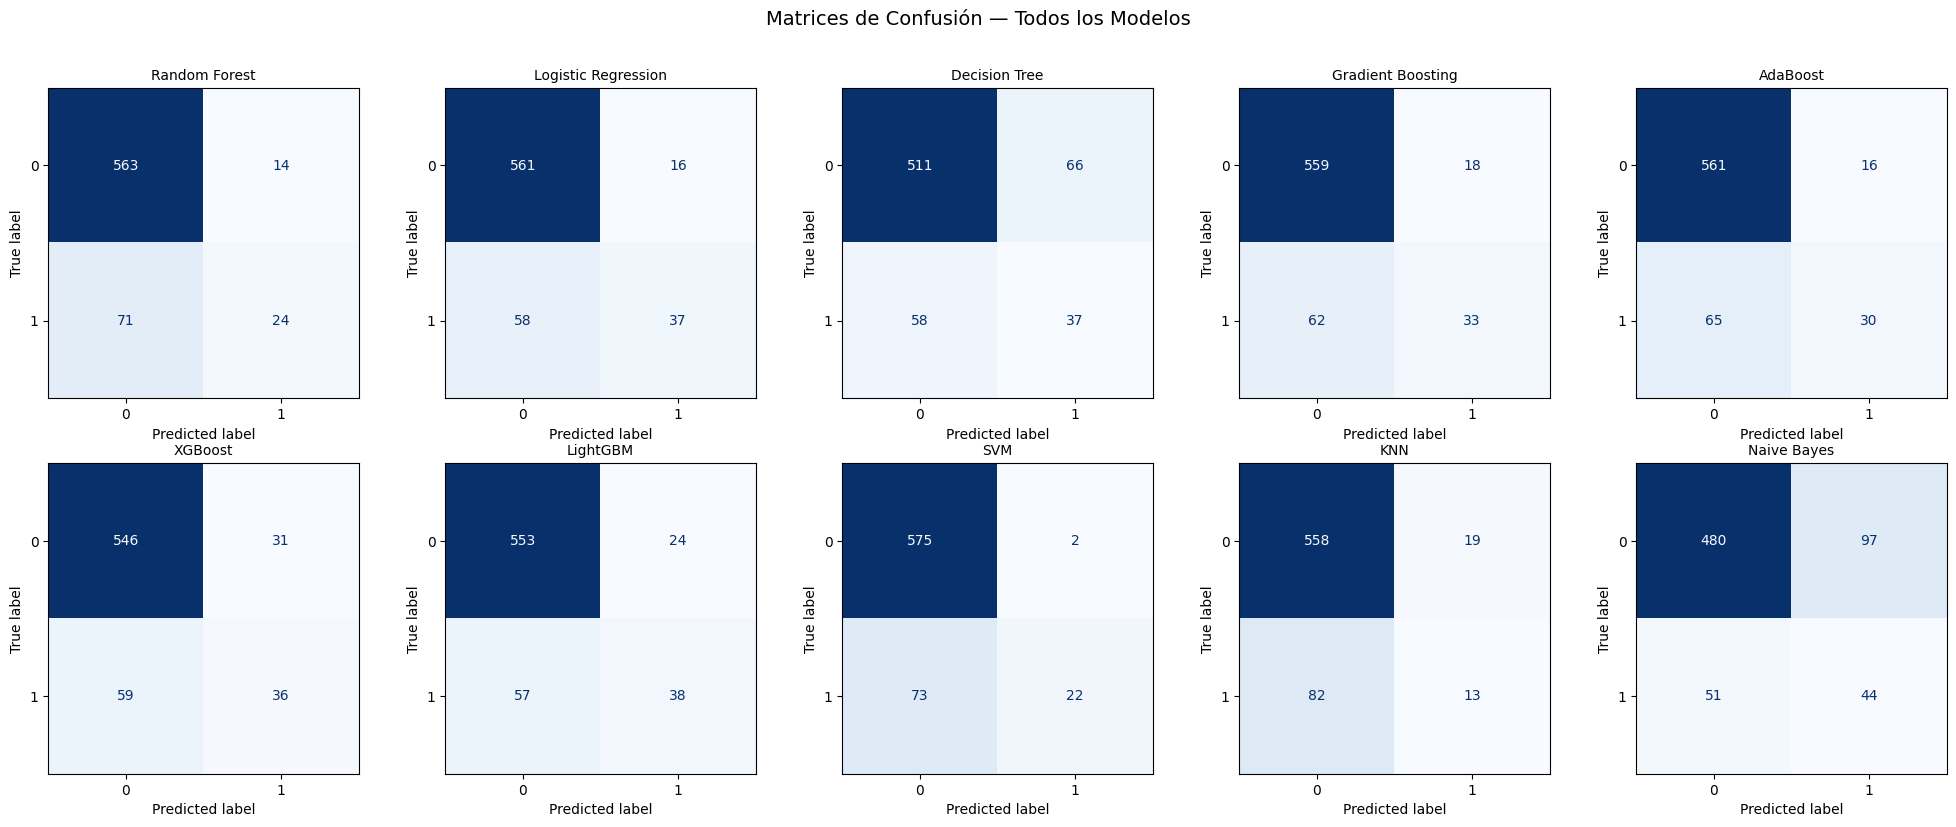

In [ ]:
n = len(trained_models)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=axes[i], cmap='Blues', colorbar=False
    )
    axes[i].set_title(name, fontsize=10)

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Matrices de Confusión — Todos los Modelos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 📋 Sección 8 — Reporte Detallado del Mejor Modelo

In [ ]:
best_model_name = results_df.iloc[0]['Modelo']
best_model      = trained_models[best_model_name]

print(f'🏆 Mejor modelo: {best_model_name}')
print(f'   Accuracy (Test):  {results_df.iloc[0]["Accuracy (Test)"]}')
print(f'   Accuracy (CV-5):  {results_df.iloc[0]["Accuracy (CV-5)"]}')
print()

y_pred_best = best_model.predict(X_test)
print('Reporte de Clasificación:')
print(classification_report(y_test, y_pred_best))

🏆 Mejor modelo: Logistic Regression
   Accuracy (Test):  0.8899
   Accuracy (CV-5):  0.8871

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       577
           1       0.70      0.39      0.50        95

    accuracy                           0.89       672
   macro avg       0.80      0.68      0.72       672
weighted avg       0.88      0.89      0.88       672



# 💾 Sección 9 — Guardar el Mejor Modelo

In [ ]:
model_filename = f'{best_model_name.lower().replace(" ", "_")}_model.pkl'
joblib.dump(best_model, model_filename)
print(f'✅ Modelo guardado como "{model_filename}".')

✅ Modelo guardado como "logistic_regression_model.pkl".


# 📂 Sección 10 — Validación con Dataset de Febrero (datos etiquetados)

In [ ]:
from google.colab import files
uploaded = files.upload()   # Selecciona el archivo de Febrero

new_data = pd.read_excel('marketing_campaign_retail_Febrero.xlsx')
display(new_data.head())

Saving marketing_campaign_retail_Febrero.xlsx to marketing_campaign_retail_Febrero (3).xlsx


,Mes,Client ID,Year_Birth,Columna Extra D,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,Febrero,5524,1957,D,Graduation,Single,58138.0,0,0,2012-09-04,...,7,0,0,0,0,0,0,3,11,1
1,Febrero,2174,1954,D,Graduation,Single,46344.0,1,1,2014-03-08,...,5,0,0,0,0,0,0,3,11,0
2,Febrero,4141,1965,D,Graduation,Together,71613.0,0,0,2013-08-21,...,4,0,0,0,0,0,0,3,11,0
3,Febrero,6182,1984,D,Graduation,Together,26646.0,1,0,2014-02-10,...,6,0,0,0,0,0,0,3,11,0
4,Febrero,5324,1981,D,PhD,Married,58293.0,1,0,2014-01-19,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
print('Nombres de las columnas de new_data:')
for col in new_data.columns:
    print(col)

Nombres de las columnas de new_data:
Mes
Client ID
Year_Birth
Columna Extra D
Education
Marital_Status
Income
Kidhome
Teenhome
Dt_Customer
Recency
MntWines
Columna Extra M
MntFruits
MntMeatProducts
MntFishProducts
MntSweetProducts
MntGoldProds
NumDealsPurchases
NumWebPurchases
NumCatalogPurchases
NumStorePurchases
NumWebVisitsMonth
AcceptedCmp3
AcceptedCmp4
AcceptedCmp5
AcceptedCmp1
AcceptedCmp2
Complain
Z_CostContact
Z_Revenue
Response


In [ ]:
# Eliminar columnas irrelevantes o que no serán usadas para el dataset de Febrero
# Based on columns of new_data and what was dropped in the January dataset
columns_to_drop_feb = ['Mes', 'Client ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue', 'Columna Extra D', 'Columna Extra M']
new_data_processed = new_data.drop(columns=columns_to_drop_feb)

# Imputar valores nulos en 'Income' si existen, antes del one-hot encoding
if 'Income' in new_data_processed.columns:
    new_data_processed['Income'].fillna(new_data_processed['Income'].median(), inplace=True)

# One-Hot Encoding de variables categóricas para el dataset de Febrero
# Usar las mismas columnas categóricas que en el dataset de Enero
categorical_cols_for_encoding_feb = [
    'Education', 'Marital_Status',
    'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain'
]
new_data_encoded = pd.get_dummies(new_data_processed, columns=categorical_cols_for_encoding_feb, drop_first=True)

# Verificar valores nulos después de todas las transformaciones
print(f'Valores nulos después de imputar y codificar en Febrero: {new_data_encoded.isnull().sum().sum()}')

# Escalar variables numéricas para el dataset de Febrero
numerical_columns_feb = [col for col in new_data_encoded.columns
                         if new_data_encoded[col].dtype in ['int64', 'float64']
                         and col not in ['Response']]

scaler_feb = StandardScaler()
new_data_encoded[numerical_columns_feb] = scaler_feb.fit_transform(new_data_encoded[numerical_columns_feb])

X_Feb = new_data_encoded.drop(columns=['Response'])
y_Feb = new_data_encoded['Response']

print('✅ Febrero preprocesado.')

Valores nulos después de imputar y codificar en Febrero: 0
✅ Febrero preprocesado.


/tmp/ipykernel_7207/1265528102.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_data_processed['Income'].fillna(new_data_processed['Income'].median(), inplace=True)


In [ ]:
# Evaluar todos los modelos sobre Febrero
feb_results = []
for name, model in trained_models.items():
    y_pred_feb = model.predict(X_Feb)
    acc_feb = accuracy_score(y_Feb, y_pred_feb)
    feb_results.append({'Modelo': name, 'Accuracy Febrero': round(acc_feb, 4)})

feb_df = pd.DataFrame(feb_results).sort_values('Accuracy Febrero', ascending=False)
display(feb_df)

# Comparar Enero vs Febrero
comparison = results_df.merge(feb_df, on='Modelo')
display(comparison)

,Modelo,Accuracy Febrero
6,LightGBM,0.9598
0,Random Forest,0.9580
5,XGBoost,0.9558
2,Decision Tree,0.9406
3,Gradient Boosting,0.9286
7,SVM,0.9036
1,Logistic Regression,0.8920
4,AdaBoost,0.8866
8,KNN,0.8772
9,Naive Bayes,0.8098


,Modelo,Accuracy (Test),Accuracy (CV-5),Accuracy Febrero
0,Logistic Regression,0.8899,0.8871,0.8920
1,SVM,0.8884,0.8786,0.9036
2,Gradient Boosting,0.8810,0.8862,0.9286
3,LightGBM,0.8795,0.8777,0.9598
4,AdaBoost,0.8795,0.8781,0.8866
5,Random Forest,0.8735,0.8781,0.9580
6,XGBoost,0.8661,0.8750,0.9558
7,KNN,0.8497,0.8571,0.8772
8,Decision Tree,0.8155,0.8446,0.9406
9,Naive Bayes,0.7798,0.8192,0.8098


# 🔮 Sección 11 — Predicción sobre Dataset de Marzo (sin etiquetas)

In [ ]:
from google.colab import files
uploaded = files.upload()   # Selecciona el archivo de Marzo

new_data_Marzo = pd.read_excel('marketing_campaign_retail_Marzo.xlsx')
display(new_data_Marzo.head())

Saving marketing_campaign_retail_Marzo.xlsx to marketing_campaign_retail_Marzo (1).xlsx


,Mes,Client ID,Year_Birth,Columna Extra D,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue
0,Marzo,5524,1957,D,Graduation,Single,58138.0,0,0,2012-09-04,...,4,7,0,0,0,0,0,0,3,11
1,Marzo,2174,1954,D,Graduation,Single,46344.0,1,1,2014-03-08,...,2,5,0,0,0,0,0,0,3,11
2,Marzo,4141,1965,D,Graduation,Together,71613.0,0,0,2013-08-21,...,10,4,0,0,0,0,0,0,3,11
3,Marzo,6182,1984,D,Graduation,Together,26646.0,1,0,2014-02-10,...,4,6,0,0,0,0,0,0,3,11
4,Marzo,5324,1981,D,PhD,Married,58293.0,1,0,2014-01-19,...,6,5,0,0,0,0,0,0,3,11


In [ ]:
# Columns to drop for March, consistent with February and January preprocessing
columns_to_drop_mar = ['Mes', 'Client ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue', 'Columna Extra D', 'Columna Extra M']
# Filter out columns that might not exist in new_data_Marzo
columns_to_drop_mar = [col for col in columns_to_drop_mar if col in new_data_Marzo.columns]
new_data_processed_mar = new_data_Marzo.drop(columns=columns_to_drop_mar)

# Impute values for 'Income' if they exist, using the median of the March data (ideally, should use median from training data)
if 'Income' in new_data_processed_mar.columns:
    new_data_processed_mar['Income'].fillna(new_data_processed_mar['Income'].median(), inplace=True)

# One-Hot Encoding for categorical variables, consistent with January/February
categorical_cols_for_encoding_mar = [
    'Education', 'Marital_Status',
    'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain'
]
# Filter to ensure only existing columns are encoded
categorical_cols_for_encoding_mar = [col for col in categorical_cols_for_encoding_mar if col in new_data_processed_mar.columns]
new_data_encoded_Marzo = pd.get_dummies(new_data_processed_mar, columns=categorical_cols_for_encoding_mar, drop_first=True)

# Verify no null values after all transformations
print(f'Valores nulos después de imputar y codificar en Marzo: {new_data_encoded_Marzo.isnull().sum().sum()}')

# Align columns with the training data (X_train) before scaling and prediction
# This step is crucial to ensure the March data has the exact same features as the training data
# and in the same order, with missing features filled with 0.
X_train_cols = X_train.columns
new_data_aligned_marzo = new_data_encoded_Marzo.reindex(columns=X_train_cols, fill_value=0)

# Scale numerical variables using the *same scaler* fitted on the training data (from 'preprocess' cell)
# The `scaler` object and `numerical_columns` list from the `preprocess` cell are globally available.
numerical_cols_to_scale_in_marzo = [col for col in numerical_columns if col in new_data_aligned_marzo.columns]

new_data_aligned_marzo[numerical_cols_to_scale_in_marzo] = scaler.transform(
    new_data_aligned_marzo[numerical_cols_to_scale_in_marzo]
)

X_Marzo = new_data_aligned_marzo

print('✅ Marzo preprocesado.')

Valores nulos después de imputar y codificar en Marzo: 0
✅ Marzo preprocesado.


/tmp/ipykernel_7207/3074705630.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_data_processed_mar['Income'].fillna(new_data_processed_mar['Income'].median(), inplace=True)


In [ ]:
# Usar el mejor modelo para predecir Marzo
probabilities   = best_model.predict_proba(X_Marzo) # Use X_Marzo (scaled and aligned) for prediction
predicted_class = probabilities.argmax(axis=1)
predicted_prob  = probabilities.max(axis=1)

results_mar = pd.DataFrame({
    'Prediccion':    predicted_class,
    'Probabilidad':  predicted_prob
})

# Combinar con dataset original de Marzo
# Reset the index and drop the old one to avoid duplicate index columns if the cell is run multiple times
new_data_Marzo_clean_index = new_data_Marzo.reset_index(drop=True)
final_results = pd.concat([new_data_Marzo_clean_index, results_mar], axis=1)

show_columns = ['Mes', 'Client ID', 'Income', 'Year_Birth', 'Prediccion', 'Probabilidad']
comparison_results = final_results[show_columns].rename(
    columns={'Prediccion': 'Response'}
)

display(comparison_results.head(10))

,Mes,Client ID,Income,Year_Birth,Response,Probabilidad
0,Marzo,5524,58138.0,1957,1,0.597913
1,Marzo,2174,46344.0,1954,0,0.963418
2,Marzo,4141,71613.0,1965,0,0.964636
3,Marzo,6182,26646.0,1984,0,0.959193
4,Marzo,5324,58293.0,1981,0,0.972353
5,Marzo,7446,62513.0,1967,0,0.964431
6,Marzo,965,55635.0,1971,0,0.885306
7,Marzo,6177,33454.0,1985,0,0.821596
8,Marzo,4855,30351.0,1974,0,0.782552
9,Marzo,5899,5648.0,1950,1,0.695358


# 📥 Sección 12 — Exportar Resultados y Descargar Archivos

In [ ]:
# Guardar predicciones de Marzo
output_path = 'digital_marketing_campaign_dataset_with_Predictions.xlsx'
comparison_results.to_excel(output_path, index=False)
print(f'✅ Predicciones guardadas en "{output_path}".')

# Guardar tabla comparativa de modelos
results_df.to_excel('comparacion_modelos.xlsx', index=False)
print('✅ Comparación de modelos guardada en "comparacion_modelos.xlsx".')

✅ Predicciones guardadas en "digital_marketing_campaign_dataset_with_Predictions.xlsx".
✅ Comparación de modelos guardada en "comparacion_modelos.xlsx".


In [ ]:
from google.colab import files
files.download(output_path)
files.download(model_filename)
files.download('comparacion_modelos.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>